# Notebook 3 - Modelado y Evaluacion

La parte mas costosa computacionalmente. Entreno seis configuraciones de modelo mas el fine-tuning completo de RoBERTa, todo en CPU (aviso: el fine-tuning son aproximadamente 4 horas).

Modelos entrenados:
- SVM (LinearSVC) con TF-IDF y con embeddings RoBERTa
- Random Forest (200 arboles) con las mismas dos representaciones
- Red neuronal feedforward (PyTorch, BatchNorm + Dropout) con TF-IDF y RoBERTa
- Fine-tuning de `roberta-base` con clasificador sobre el token [CLS]

**Metrica principal: F1-macro**, porque el dataset tiene ~69% de ejemplos `non-rumour` y la accuracy sola seria demasiado optimista.

Los splits de TF-IDF usan todos los tweets; los embeddings solo sobre source tweets (ver NB2 para el razonamiento).


## 0. Instalación de dependencias

In [1]:
# Ejecutar solo si no están instaladas
# import sys
# !{sys.executable} -m pip install torch transformers scikit-learn accelerate

## 1. Imports y configuración

In [2]:
import os
import pickle
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import scipy.sparse as sp

# Scikit-learn
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, roc_auc_score
)
from sklearn.preprocessing import label_binarize

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# HuggingFace
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

BASE_DIR      = os.path.abspath(os.path.join(os.getcwd(), '..'))
RESULTS_DIR   = os.path.join(BASE_DIR, 'results')
PROCESSED_DIR = os.path.join(BASE_DIR, 'data', 'processed')
VECTORS_DIR   = os.path.join(BASE_DIR, 'data', 'vectors')
MODELS_DIR    = os.path.join(BASE_DIR, 'models')

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'Dispositivo: {DEVICE}')
print('Imports OK')

Dispositivo: cpu
Imports OK


## 2. Carga de datos y vectores

In [3]:
# Splits completos (para TF-IDF)
with open(os.path.join(PROCESSED_DIR, 'splits.pkl'), 'rb') as f:
    splits = pickle.load(f)

X_train_text = splits['X_train']
X_val_text   = splits['X_val']
X_test_text  = splits['X_test']
y_train      = splits['y_train']
y_val        = splits['y_val']
y_test       = splits['y_test']
label_names  = splits['label_names']
le_veracity  = splits['le_veracity']
n_classes    = len(label_names)

# Splits source (para embeddings)
with open(os.path.join(PROCESSED_DIR, 'splits_source.pkl'), 'rb') as f:
    src_splits = pickle.load(f)

X_src_train = src_splits['X_train']
X_src_val   = src_splits['X_val']
X_src_test  = src_splits['X_test']
y_src_train = src_splits['y_train']
y_src_val   = src_splits['y_val']
y_src_test  = src_splits['y_test']

# Vectores TF-IDF
X_train_tfidf = sp.load_npz(os.path.join(VECTORS_DIR, 'tfidf_train.npz'))
X_val_tfidf   = sp.load_npz(os.path.join(VECTORS_DIR, 'tfidf_val.npz'))
X_test_tfidf  = sp.load_npz(os.path.join(VECTORS_DIR, 'tfidf_test.npz'))

# Vectores RoBERTa
X_train_roberta = np.load(os.path.join(VECTORS_DIR, 'roberta_train.npy'))
X_val_roberta   = np.load(os.path.join(VECTORS_DIR, 'roberta_val.npy'))
X_test_roberta  = np.load(os.path.join(VECTORS_DIR, 'roberta_test.npy'))

# Vectores Word2Vec
X_train_w2v = np.load(os.path.join(VECTORS_DIR, 'w2v_train.npy'))
X_val_w2v   = np.load(os.path.join(VECTORS_DIR, 'w2v_val.npy'))
X_test_w2v  = np.load(os.path.join(VECTORS_DIR, 'w2v_test.npy'))

print(f'Clases: {label_names}')
print(f'TF-IDF  — Train: {X_train_tfidf.shape} | Val: {X_val_tfidf.shape} | Test: {X_test_tfidf.shape}')
print(f'RoBERTa — Train: {X_train_roberta.shape} | Val: {X_val_roberta.shape} | Test: {X_test_roberta.shape}')
print(f'Word2Vec — Train: {X_train_w2v.shape} | Val: {X_val_w2v.shape} | Test: {X_test_w2v.shape}')

Clases: ['false', 'non-rumour', 'true', 'unverified']
TF-IDF  — Train: (67855, 20000) | Val: (14540, 20000) | Test: (14541, 20000)
RoBERTa — Train: (4483, 768) | Val: (961, 768) | Test: (961, 768)
Word2Vec — Train: (4483, 768) | Val: (961, 768) | Test: (961, 768)


## 3. Funciones de evaluación

In [4]:
all_results = []  # Tabla comparativa final

def evaluate_model(name: str, y_true: np.ndarray, y_pred: np.ndarray,
                   y_prob: np.ndarray = None) -> dict:
    """Calcula métricas y guarda resultados."""
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average='macro', zero_division=0)

    if y_prob is not None and n_classes > 1:
        y_bin = label_binarize(y_true, classes=list(range(n_classes)))
        try:
            auc = roc_auc_score(y_bin, y_prob, multi_class='ovr', average='macro')
        except Exception:
            auc = float('nan')
    else:
        auc = float('nan')

    result = {'Modelo': name, 'Accuracy': acc, 'F1-macro': f1, 'ROC-AUC': auc}
    all_results.append(result)

    print(f'\n{name}')
    print(f'  Accuracy: {acc:.4f} | F1-macro: {f1:.4f} | ROC-AUC: {auc:.4f}')
    print(classification_report(y_true, y_pred, target_names=label_names, zero_division=0))
    return result


def plot_confusion_matrix(y_true, y_pred, title, filename):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_names, yticklabels=label_names, ax=ax)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Predicho')
    ax.set_ylabel('Real')
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, filename), bbox_inches='tight')
    plt.show()

print('Funciones de evaluacion listas.')

Funciones de evaluacion listas.


## 4. Modelos Scikit-learn

### 4.1 SVM con TF-IDF

Entrenando SVM + TF-IDF...

SVM + TF-IDF
  Accuracy: 0.6637 | F1-macro: 0.4843 | ROC-AUC: nan
              precision    recall  f1-score   support

       false       0.30      0.40      0.34       890
  non-rumour       0.80      0.79      0.79      9979
        true       0.42      0.40      0.41      2107
  unverified       0.39      0.39      0.39      1565

    accuracy                           0.66     14541
   macro avg       0.48      0.49      0.48     14541
weighted avg       0.67      0.66      0.67     14541



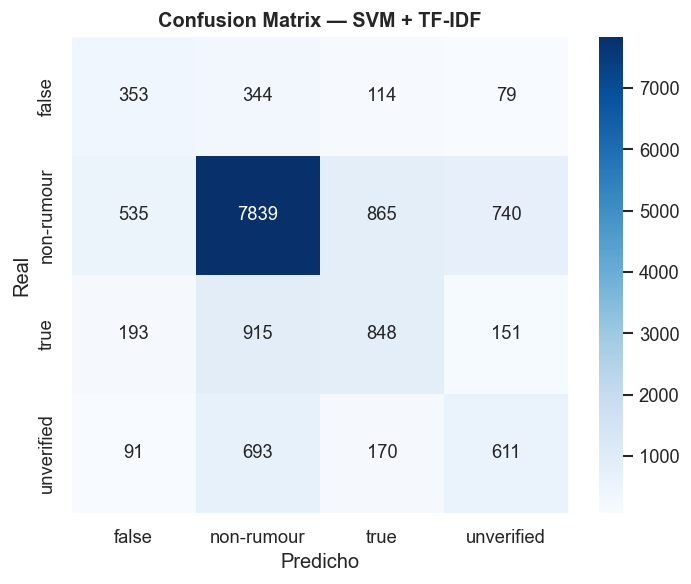

In [5]:
print('Entrenando SVM + TF-IDF...')
svm_tfidf = LinearSVC(max_iter=2000, random_state=RANDOM_STATE, class_weight='balanced')
svm_tfidf.fit(X_train_tfidf, y_train)

y_pred_svm_tfidf = svm_tfidf.predict(X_test_tfidf)
evaluate_model('SVM + TF-IDF', y_test, y_pred_svm_tfidf)
plot_confusion_matrix(y_test, y_pred_svm_tfidf,
                      'Confusion Matrix — SVM + TF-IDF', '11_cm_svm_tfidf.png')

### 4.2 SVM con RoBERTa

Entrenando SVM + RoBERTa...

SVM + RoBERTa
  Accuracy: 0.7575 | F1-macro: 0.6701 | ROC-AUC: nan
              precision    recall  f1-score   support

       false       0.67      0.75      0.71        96
  non-rumour       0.87      0.83      0.85       601
        true       0.57      0.68      0.62       160
  unverified       0.53      0.48      0.51       104

    accuracy                           0.76       961
   macro avg       0.66      0.68      0.67       961
weighted avg       0.77      0.76      0.76       961



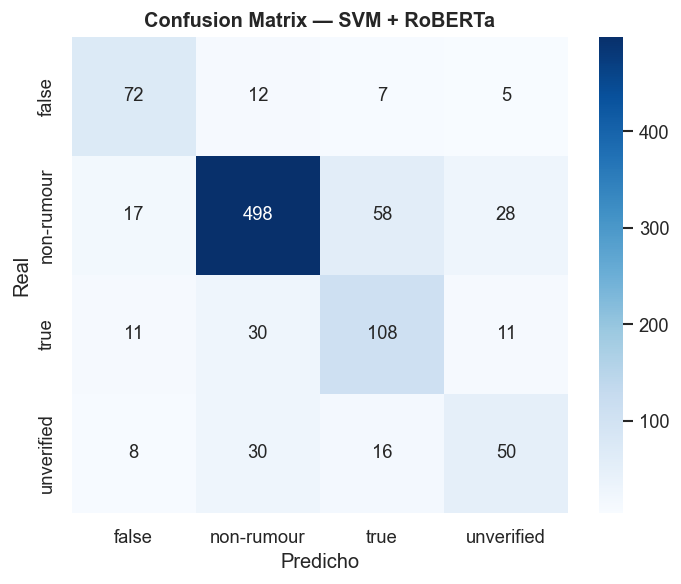

In [6]:
print('Entrenando SVM + RoBERTa...')
svm_roberta = LinearSVC(max_iter=2000, random_state=RANDOM_STATE, class_weight='balanced')
svm_roberta.fit(X_train_roberta, y_src_train)

y_pred_svm_roberta = svm_roberta.predict(X_test_roberta)
evaluate_model('SVM + RoBERTa', y_src_test, y_pred_svm_roberta)
plot_confusion_matrix(y_src_test, y_pred_svm_roberta,
                      'Confusion Matrix — SVM + RoBERTa', '12_cm_svm_roberta.png')

### 4.3 Random Forest con TF-IDF

Entrenando Random Forest + TF-IDF...

Random Forest + TF-IDF
  Accuracy: 0.7207 | F1-macro: 0.4706 | ROC-AUC: 0.7489
              precision    recall  f1-score   support

       false       0.41      0.30      0.35       890
  non-rumour       0.75      0.93      0.83      9979
        true       0.61      0.28      0.38      2107
  unverified       0.60      0.22      0.32      1565

    accuracy                           0.72     14541
   macro avg       0.59      0.43      0.47     14541
weighted avg       0.69      0.72      0.68     14541



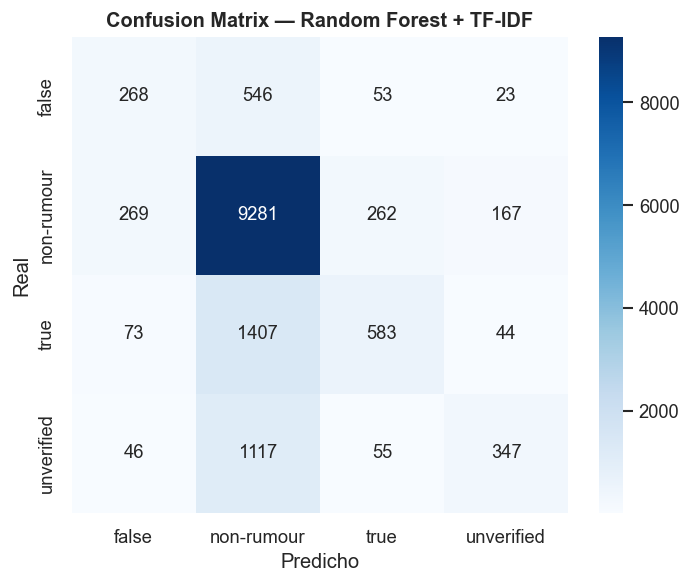

In [7]:
print('Entrenando Random Forest + TF-IDF...')
rf_tfidf = RandomForestClassifier(
    n_estimators=200, random_state=RANDOM_STATE,
    class_weight='balanced', n_jobs=-1
)
rf_tfidf.fit(X_train_tfidf, y_train)

y_pred_rf_tfidf = rf_tfidf.predict(X_test_tfidf)
y_prob_rf_tfidf = rf_tfidf.predict_proba(X_test_tfidf)
evaluate_model('Random Forest + TF-IDF', y_test, y_pred_rf_tfidf, y_prob_rf_tfidf)
plot_confusion_matrix(y_test, y_pred_rf_tfidf,
                      'Confusion Matrix — Random Forest + TF-IDF', '13_cm_rf_tfidf.png')

### 4.4 Random Forest con RoBERTa

Entrenando Random Forest + RoBERTa...

Random Forest + RoBERTa
  Accuracy: 0.7097 | F1-macro: 0.4744 | ROC-AUC: 0.9013
              precision    recall  f1-score   support

       false       0.97      0.29      0.45        96
  non-rumour       0.69      0.99      0.81       601
        true       0.87      0.29      0.43       160
  unverified       0.92      0.12      0.21       104

    accuracy                           0.71       961
   macro avg       0.86      0.42      0.47       961
weighted avg       0.77      0.71      0.65       961



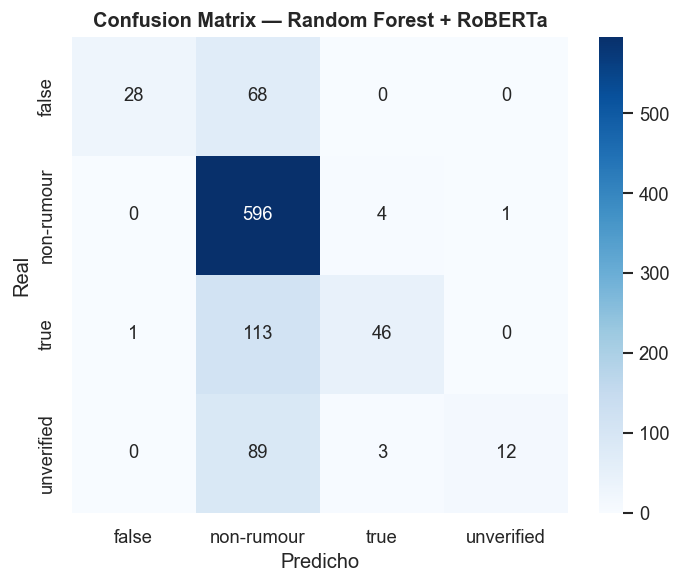

In [8]:
print('Entrenando Random Forest + RoBERTa...')
rf_roberta = RandomForestClassifier(
    n_estimators=200, random_state=RANDOM_STATE,
    class_weight='balanced', n_jobs=-1
)
rf_roberta.fit(X_train_roberta, y_src_train)

y_pred_rf_roberta = rf_roberta.predict(X_test_roberta)
y_prob_rf_roberta = rf_roberta.predict_proba(X_test_roberta)
evaluate_model('Random Forest + RoBERTa', y_src_test, y_pred_rf_roberta, y_prob_rf_roberta)
plot_confusion_matrix(y_src_test, y_pred_rf_roberta,
                      'Confusion Matrix — Random Forest + RoBERTa', '14_cm_rf_roberta.png')

## 5. Red neuronal (PyTorch)

In [9]:
class TextClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim, n_classes, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, n_classes),
        )
    def forward(self, x):
        return self.net(x)


def sparse_to_batches(X_sparse, y, batch_size):
    """Genera mini-batches desde matriz sparse sin convertirla completa a denso."""
    n = X_sparse.shape[0]
    idx = np.random.permutation(n)
    for start in range(0, n, batch_size):
        batch_idx = idx[start: start + batch_size]
        X_batch = torch.tensor(
            X_sparse[batch_idx].toarray(), dtype=torch.float32
        )
        y_batch = torch.tensor(y[batch_idx], dtype=torch.long)
        yield X_batch, y_batch


def train_nn(X_tr, y_tr, X_vl, y_vl, input_dim,
             hidden_dim=256, epochs=30, batch_size=64,
             lr=1e-3, model_name='nn'):
    """
    Entrena la red neuronal.
    Soporta matrices sparse (TF-IDF) sin convertirlas enteras a denso.
    """
    is_sparse = sp.issparse(X_tr)

    class_counts  = np.bincount(y_tr)
    class_weights = torch.tensor(
        1.0 / class_counts * class_counts.sum() / n_classes,
        dtype=torch.float32
    ).to(DEVICE)

    model     = TextClassifier(input_dim, hidden_dim, n_classes).to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    history    = {'train_loss': [], 'val_loss': [], 'val_f1': []}
    best_f1    = 0
    best_state = None

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        n_batches  = 0

        if is_sparse:
            batches = sparse_to_batches(X_tr, y_tr, batch_size)
        else:
            X_tr_t = torch.tensor(X_tr, dtype=torch.float32)
            y_tr_t = torch.tensor(y_tr, dtype=torch.long)
            loader = DataLoader(TensorDataset(X_tr_t, y_tr_t),
                                batch_size=batch_size, shuffle=True)
            batches = loader

        for X_batch, y_batch in batches:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            train_loss += loss.item()
            n_batches  += 1

        scheduler.step()

        # Validacion (en batches si es sparse)
        model.eval()
        val_preds = []
        val_loss  = 0
        with torch.no_grad():
            if is_sparse:
                vl_batches = list(sparse_to_batches(X_vl, y_vl, batch_size=256))
            else:
                X_vl_t = torch.tensor(X_vl, dtype=torch.float32)
                y_vl_t = torch.tensor(y_vl, dtype=torch.long)
                vl_batches = [(X_vl_t, y_vl_t)]

            for X_b, y_b in vl_batches:
                out      = model(X_b.to(DEVICE))
                val_loss += criterion(out, y_b.to(DEVICE)).item()
                val_preds.extend(out.argmax(dim=1).cpu().numpy())

        val_f1 = f1_score(y_vl, val_preds, average='macro', zero_division=0)
        history['train_loss'].append(train_loss / n_batches)
        history['val_loss'].append(val_loss)
        history['val_f1'].append(val_f1)

        if val_f1 > best_f1:
            best_f1    = val_f1
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

        if (epoch + 1) % 5 == 0:
            print(f'  Epoch {epoch+1:2d}/{epochs} — '
                  f'loss: {history["train_loss"][-1]:.4f} | '
                  f'val_loss: {history["val_loss"][-1]:.4f} | '
                  f'val_F1: {val_f1:.4f}')

    model.load_state_dict(best_state)
    torch.save(model.state_dict(), os.path.join(MODELS_DIR, f'{model_name}.pt'))
    print(f'  Mejor val F1: {best_f1:.4f}')
    return model, history


print('Arquitectura y funciones de entrenamiento listas.')


Arquitectura y funciones de entrenamiento listas.


### 5.1 Red neuronal con TF-IDF

In [10]:
print('Entrenando Red Neuronal + TF-IDF...')
nn_tfidf, hist_tfidf = train_nn(
    X_train_tfidf, y_train,
    X_val_tfidf,   y_val,
    input_dim=X_train_tfidf.shape[1],
    hidden_dim=512, epochs=30, lr=1e-3,
    model_name='nn_tfidf'
)

Entrenando Red Neuronal + TF-IDF...
  Epoch  5/30 — loss: 0.2935 | val_loss: 161.1720 | val_F1: 0.2454
  Epoch 10/30 — loss: 0.1536 | val_loss: 259.9550 | val_F1: 0.2549
  Epoch 15/30 — loss: 0.1066 | val_loss: 311.1469 | val_F1: 0.2543
  Epoch 20/30 — loss: 0.0827 | val_loss: 343.9181 | val_F1: 0.2486
  Epoch 25/30 — loss: 0.0733 | val_loss: 384.1233 | val_F1: 0.2450
  Epoch 30/30 — loss: 0.0673 | val_loss: 399.9869 | val_F1: 0.2406
  Mejor val F1: 0.2582



Red Neuronal + TF-IDF
  Accuracy: 0.6486 | F1-macro: 0.4733 | ROC-AUC: 0.7416
              precision    recall  f1-score   support

       false       0.31      0.37      0.34       890
  non-rumour       0.79      0.77      0.78      9979
        true       0.42      0.38      0.40      2107
  unverified       0.34      0.41      0.37      1565

    accuracy                           0.65     14541
   macro avg       0.47      0.48      0.47     14541
weighted avg       0.66      0.65      0.65     14541



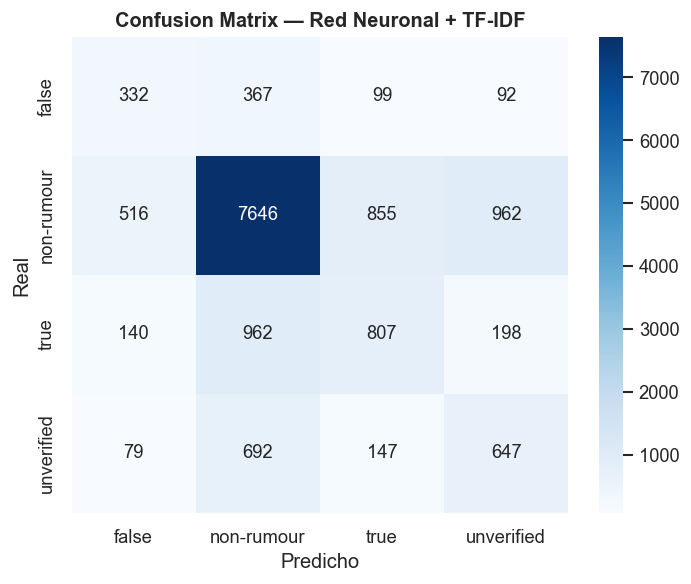

In [11]:
# Evaluar en test (en batches para no saturar memoria)
nn_tfidf.eval()
test_preds_nn = []
test_probs_nn = []

with torch.no_grad():
    for start in range(0, X_test_tfidf.shape[0], 256):
        X_b = torch.tensor(
            X_test_tfidf[start: start + 256].toarray(),
            dtype=torch.float32
        ).to(DEVICE)
        out = nn_tfidf(X_b)
        test_probs_nn.extend(torch.softmax(out, dim=1).cpu().numpy())
        test_preds_nn.extend(out.argmax(dim=1).cpu().numpy())

test_preds_nn = np.array(test_preds_nn)
test_probs_nn = np.array(test_probs_nn)

evaluate_model('Red Neuronal + TF-IDF', y_test, test_preds_nn, test_probs_nn)
plot_confusion_matrix(y_test, test_preds_nn,
                      'Confusion Matrix — Red Neuronal + TF-IDF', '15_cm_nn_tfidf.png')


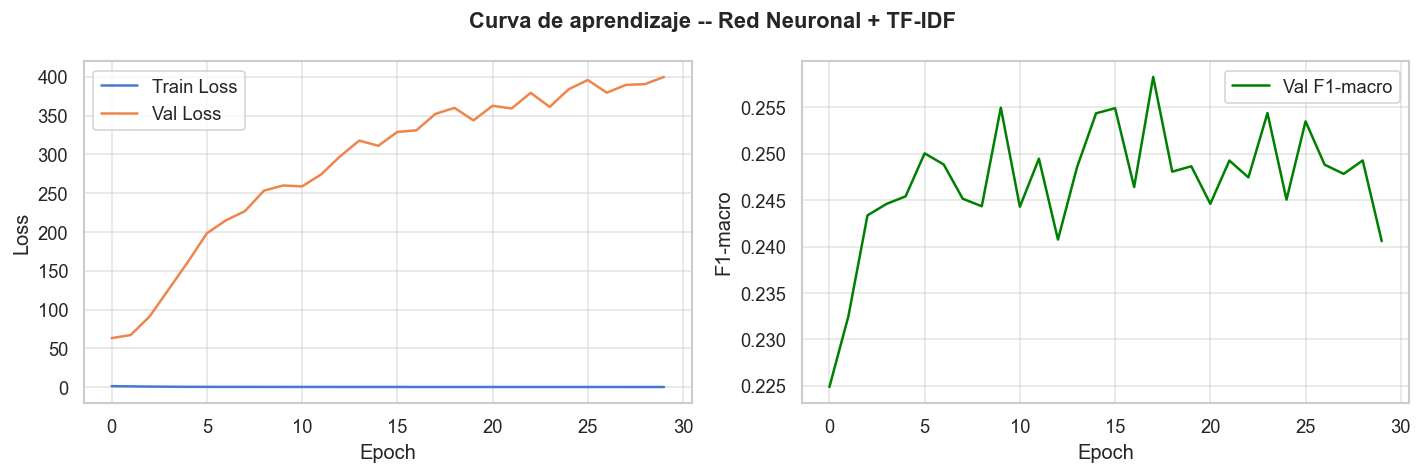

In [12]:
# Curva de aprendizaje TF-IDF
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Curva de aprendizaje -- Red Neuronal + TF-IDF', fontweight='bold')

axes[0].plot(hist_tfidf['train_loss'], label='Train Loss')
axes[0].plot(hist_tfidf['val_loss'],   label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(hist_tfidf['val_f1'], color='green', label='Val F1-macro')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('F1-macro')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '16_learning_curve_nn_tfidf.png'), bbox_inches='tight')
plt.show()

### 5.2 Red neuronal con RoBERTa

Entrenando Red Neuronal + RoBERTa...
  Epoch  5/30 — loss: 0.6209 | val_loss: 0.8007 | val_F1: 0.6342
  Epoch 10/30 — loss: 0.3838 | val_loss: 0.9351 | val_F1: 0.6735
  Epoch 15/30 — loss: 0.2392 | val_loss: 1.0204 | val_F1: 0.6730
  Epoch 20/30 — loss: 0.1561 | val_loss: 0.8472 | val_F1: 0.6845
  Epoch 25/30 — loss: 0.1287 | val_loss: 0.9857 | val_F1: 0.7091
  Epoch 30/30 — loss: 0.1054 | val_loss: 1.0069 | val_F1: 0.7173
  Mejor val F1: 0.7267

Red Neuronal + RoBERTa
  Accuracy: 0.7971 | F1-macro: 0.7237 | ROC-AUC: 0.9241
              precision    recall  f1-score   support

       false       0.86      0.71      0.78        96
  non-rumour       0.89      0.86      0.88       601
        true       0.61      0.77      0.68       160
  unverified       0.59      0.54      0.56       104

    accuracy                           0.80       961
   macro avg       0.74      0.72      0.72       961
weighted avg       0.81      0.80      0.80       961



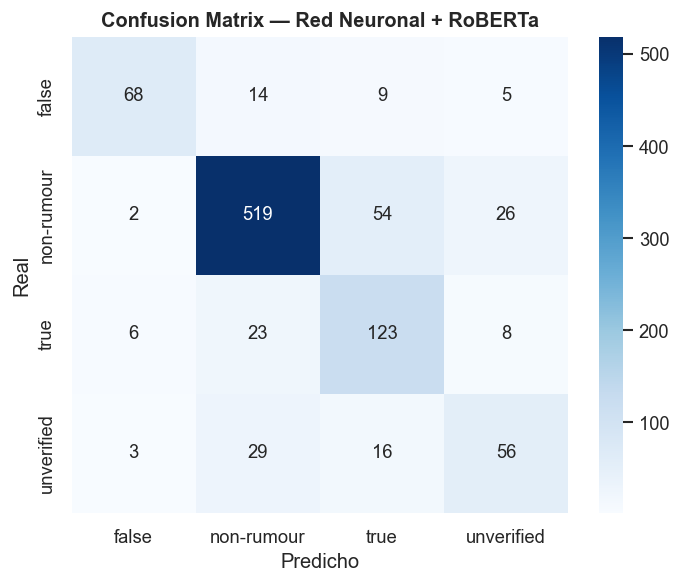

In [13]:
print('Entrenando Red Neuronal + RoBERTa...')
nn_roberta, hist_roberta = train_nn(
    X_train_roberta, y_src_train,
    X_val_roberta,   y_src_val,
    input_dim=768,
    hidden_dim=256, epochs=30, lr=1e-3,
    model_name='nn_roberta'
)

# Evaluar en test
nn_roberta.eval()
X_test_t = torch.tensor(X_test_roberta, dtype=torch.float32).to(DEVICE)
with torch.no_grad():
    out   = nn_roberta(X_test_t)
    probs = torch.softmax(out, dim=1).cpu().numpy()
    preds = out.argmax(dim=1).cpu().numpy()

evaluate_model('Red Neuronal + RoBERTa', y_src_test, preds, probs)
plot_confusion_matrix(y_src_test, preds,
                      'Confusion Matrix — Red Neuronal + RoBERTa', '17_cm_nn_roberta.png')

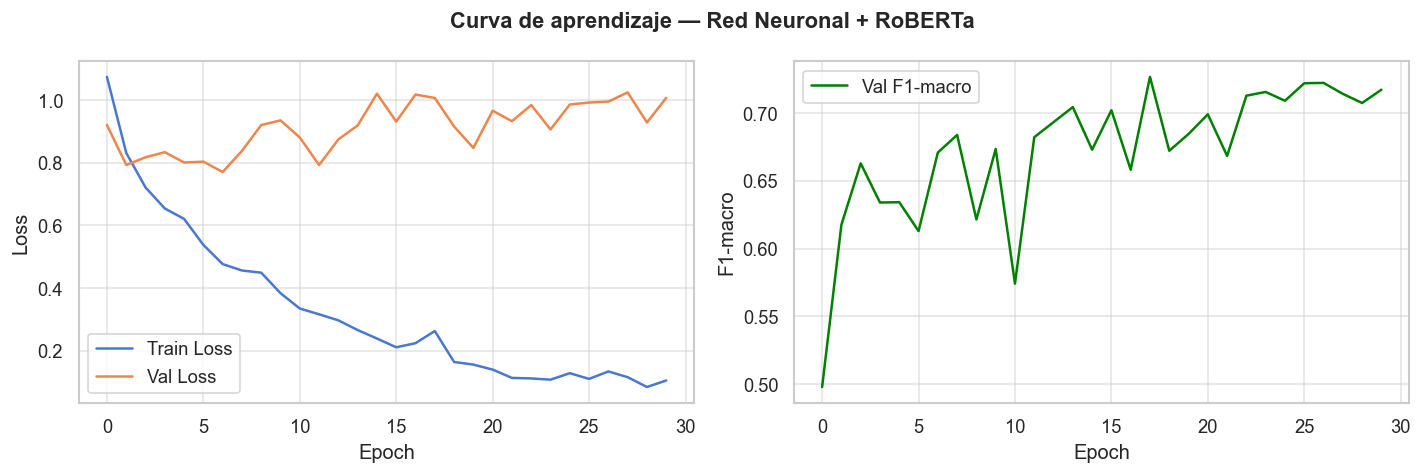

In [14]:
# Curva de aprendizaje RoBERTa
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Curva de aprendizaje — Red Neuronal + RoBERTa', fontweight='bold')

axes[0].plot(hist_roberta['train_loss'], label='Train Loss')
axes[0].plot(hist_roberta['val_loss'],   label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(hist_roberta['val_f1'], color='green', label='Val F1-macro')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('F1-macro')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '18_learning_curve_nn_roberta.png'), bbox_inches='tight')
plt.show()

## 6. Fine-tuning RoBERTa (HuggingFace)

In [15]:
from torch.utils.data import Dataset

class TweetDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts      = texts
        self.labels     = labels
        self.tokenizer  = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]),
            truncation=True,
            max_length=self.max_length,
            padding='max_length',
            return_tensors='pt'
        )
        return {
            'input_ids':      encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'label':          torch.tensor(self.labels[idx], dtype=torch.long)
        }


MODEL_NAME = 'roberta-base'
print(f'Cargando tokenizer {MODEL_NAME}...')
ft_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Datasets
train_dataset = TweetDataset(X_src_train, y_src_train, ft_tokenizer)
val_dataset   = TweetDataset(X_src_val,   y_src_val,   ft_tokenizer)
test_dataset  = TweetDataset(X_src_test,  y_src_test,  ft_tokenizer)

BATCH_SIZE = 16
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE)

print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)}')

Cargando tokenizer roberta-base...
Train batches: 281 | Val batches: 61


In [16]:
# Cargar modelo para clasificacion
print(f'Cargando {MODEL_NAME} para fine-tuning...')
ft_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=n_classes, ignore_mismatched_sizes=True
)
ft_model = ft_model.to(DEVICE)

# Pesos de clase
class_counts  = np.bincount(y_src_train)
class_weights = torch.tensor(
    1.0 / class_counts * class_counts.sum() / n_classes,
    dtype=torch.float32
).to(DEVICE)

EPOCHS    = 4
optimizer = torch.optim.AdamW(ft_model.parameters(), lr=2e-5, weight_decay=0.01)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=total_steps // 10,
    num_training_steps=total_steps
)
criterion = nn.CrossEntropyLoss(weight=class_weights)

print(f'Fine-tuning durante {EPOCHS} epochs...')
print(f'Total pasos: {total_steps}')

Cargando roberta-base para fine-tuning...


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 15271.75it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Fine-tuning durante 4 epochs...
Total pasos: 1124


In [17]:
ft_history = {'train_loss': [], 'val_loss': [], 'val_f1': []}
best_f1    = 0
best_state = None

for epoch in range(EPOCHS):
    # Train
    ft_model.train()
    train_loss = 0
    for batch in tqdm(train_loader, desc=f'Epoch {epoch+1}/{EPOCHS} [Train]'):
        input_ids = batch['input_ids'].to(DEVICE)
        attn_mask = batch['attention_mask'].to(DEVICE)
        labels    = batch['label'].to(DEVICE)

        optimizer.zero_grad()
        outputs = ft_model(input_ids=input_ids, attention_mask=attn_mask)
        loss    = criterion(outputs.logits, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(ft_model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        train_loss += loss.item()

    # Validation
    ft_model.eval()
    val_loss  = 0
    val_preds = []
    val_true  = []
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(DEVICE)
            attn_mask = batch['attention_mask'].to(DEVICE)
            labels    = batch['label'].to(DEVICE)
            outputs   = ft_model(input_ids=input_ids, attention_mask=attn_mask)
            loss      = criterion(outputs.logits, labels)
            val_loss += loss.item()
            val_preds.extend(outputs.logits.argmax(dim=1).cpu().numpy())
            val_true.extend(labels.cpu().numpy())

    val_f1 = f1_score(val_true, val_preds, average='macro', zero_division=0)
    ft_history['train_loss'].append(train_loss / len(train_loader))
    ft_history['val_loss'].append(val_loss / len(val_loader))
    ft_history['val_f1'].append(val_f1)

    print(f'Epoch {epoch+1}/{EPOCHS} — '
          f'train_loss: {ft_history["train_loss"][-1]:.4f} | '
          f'val_loss: {ft_history["val_loss"][-1]:.4f} | '
          f'val_F1: {val_f1:.4f}')

    if val_f1 > best_f1:
        best_f1    = val_f1
        best_state = {k: v.clone() for k, v in ft_model.state_dict().items()}

ft_model.load_state_dict(best_state)
ft_model.save_pretrained(os.path.join(MODELS_DIR, 'roberta_finetuned'))
ft_tokenizer.save_pretrained(os.path.join(MODELS_DIR, 'roberta_finetuned'))
print(f'\nMejor val F1: {best_f1:.4f}')
print('Modelo guardado.')

Epoch 1/4 [Train]: 100%|██████████| 281/281 [14:11<00:00,  3.03s/it]


Epoch 1/4 — train_loss: 1.1086 | val_loss: 0.7383 | val_F1: 0.6468


Epoch 2/4 [Train]: 100%|██████████| 281/281 [14:32<00:00,  3.10s/it]


Epoch 2/4 — train_loss: 0.6832 | val_loss: 0.7062 | val_F1: 0.7102


Epoch 3/4 [Train]: 100%|██████████| 281/281 [14:15<00:00,  3.04s/it]


Epoch 3/4 — train_loss: 0.4608 | val_loss: 0.7096 | val_F1: 0.7034


Epoch 4/4 [Train]: 100%|██████████| 281/281 [15:45<00:00,  3.37s/it]


Epoch 4/4 — train_loss: 0.2949 | val_loss: 0.7694 | val_F1: 0.7309


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.91it/s]


Mejor val F1: 0.7309
Modelo guardado.


Evaluando test: 100%|██████████| 61/61 [00:59<00:00,  1.03it/s]



Fine-tuning RoBERTa
  Accuracy: 0.8200 | F1-macro: 0.7652 | ROC-AUC: 0.9419
              precision    recall  f1-score   support

       false       0.74      0.85      0.79        96
  non-rumour       0.94      0.84      0.88       601
        true       0.66      0.82      0.74       160
  unverified       0.62      0.68      0.65       104

    accuracy                           0.82       961
   macro avg       0.74      0.80      0.77       961
weighted avg       0.84      0.82      0.83       961



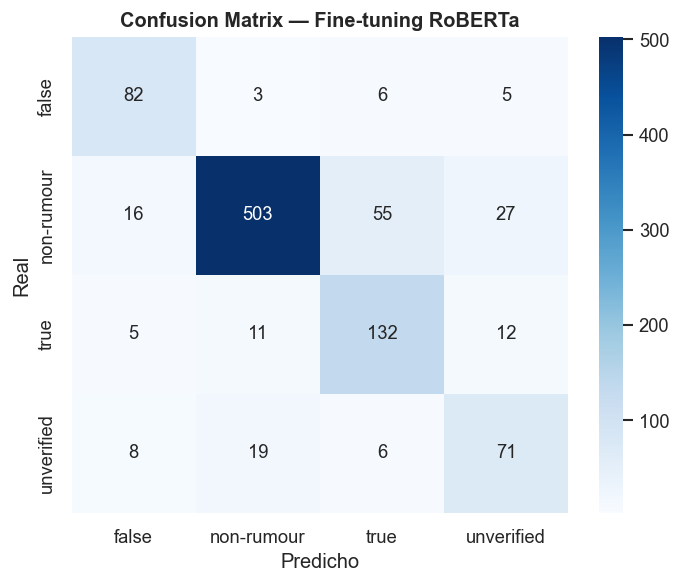

In [18]:
# Evaluar fine-tuning en test
ft_model.eval()
test_preds = []
test_probs = []
test_true  = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc='Evaluando test'):
        input_ids = batch['input_ids'].to(DEVICE)
        attn_mask = batch['attention_mask'].to(DEVICE)
        outputs   = ft_model(input_ids=input_ids, attention_mask=attn_mask)
        probs     = torch.softmax(outputs.logits, dim=1).cpu().numpy()
        preds     = outputs.logits.argmax(dim=1).cpu().numpy()
        test_preds.extend(preds)
        test_probs.extend(probs)
        test_true.extend(batch['label'].numpy())

test_preds = np.array(test_preds)
test_probs = np.array(test_probs)
test_true  = np.array(test_true)

evaluate_model('Fine-tuning RoBERTa', test_true, test_preds, test_probs)
plot_confusion_matrix(test_true, test_preds,
                      'Confusion Matrix — Fine-tuning RoBERTa', '19_cm_roberta_ft.png')

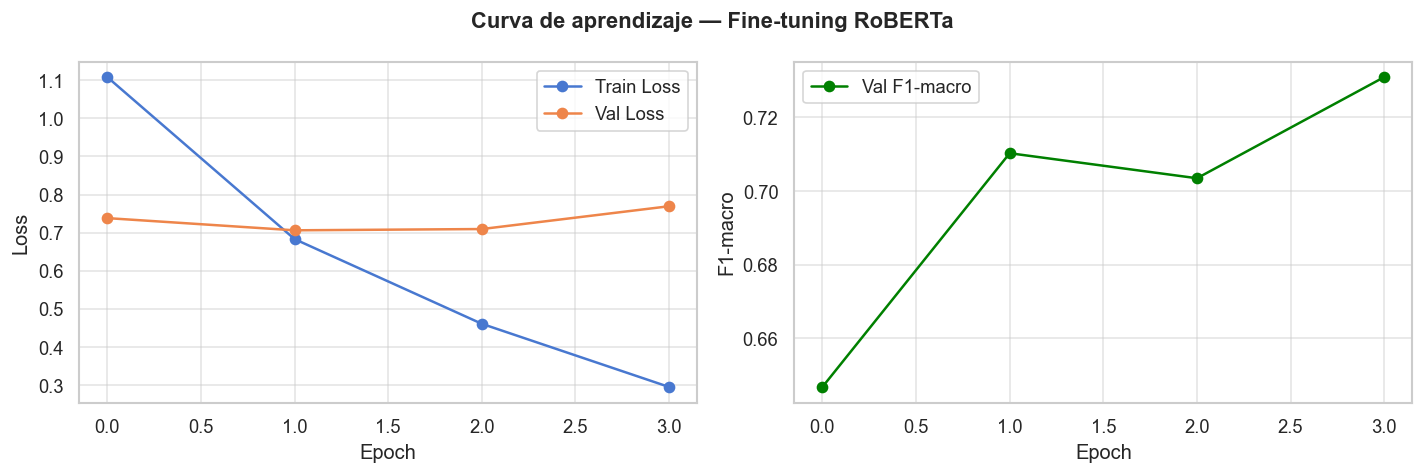

In [19]:
# Curva de aprendizaje fine-tuning
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Curva de aprendizaje — Fine-tuning RoBERTa', fontweight='bold')

axes[0].plot(ft_history['train_loss'], label='Train Loss', marker='o')
axes[0].plot(ft_history['val_loss'],   label='Val Loss',   marker='o')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(ft_history['val_f1'], color='green', label='Val F1-macro', marker='o')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('F1-macro')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '20_learning_curve_roberta_ft.png'), bbox_inches='tight')
plt.show()

## 7. Evaluación comparativa final

In [20]:
df_results = pd.DataFrame(all_results)
df_results = df_results.sort_values('F1-macro', ascending=False).reset_index(drop=True)

print('=' * 65)
print('EVALUACION COMPARATIVA FINAL — TEST SET')
print('=' * 65)
print(df_results.to_string(index=False, float_format='{:.4f}'.format))

EVALUACION COMPARATIVA FINAL — TEST SET
                 Modelo  Accuracy  F1-macro  ROC-AUC
    Fine-tuning RoBERTa    0.8200    0.7652   0.9419
 Red Neuronal + RoBERTa    0.7971    0.7237   0.9241
          SVM + RoBERTa    0.7575    0.6701      NaN
           SVM + TF-IDF    0.6637    0.4843      NaN
Random Forest + RoBERTa    0.7097    0.4744   0.9013
  Red Neuronal + TF-IDF    0.6486    0.4733   0.7416
 Random Forest + TF-IDF    0.7207    0.4706   0.7489


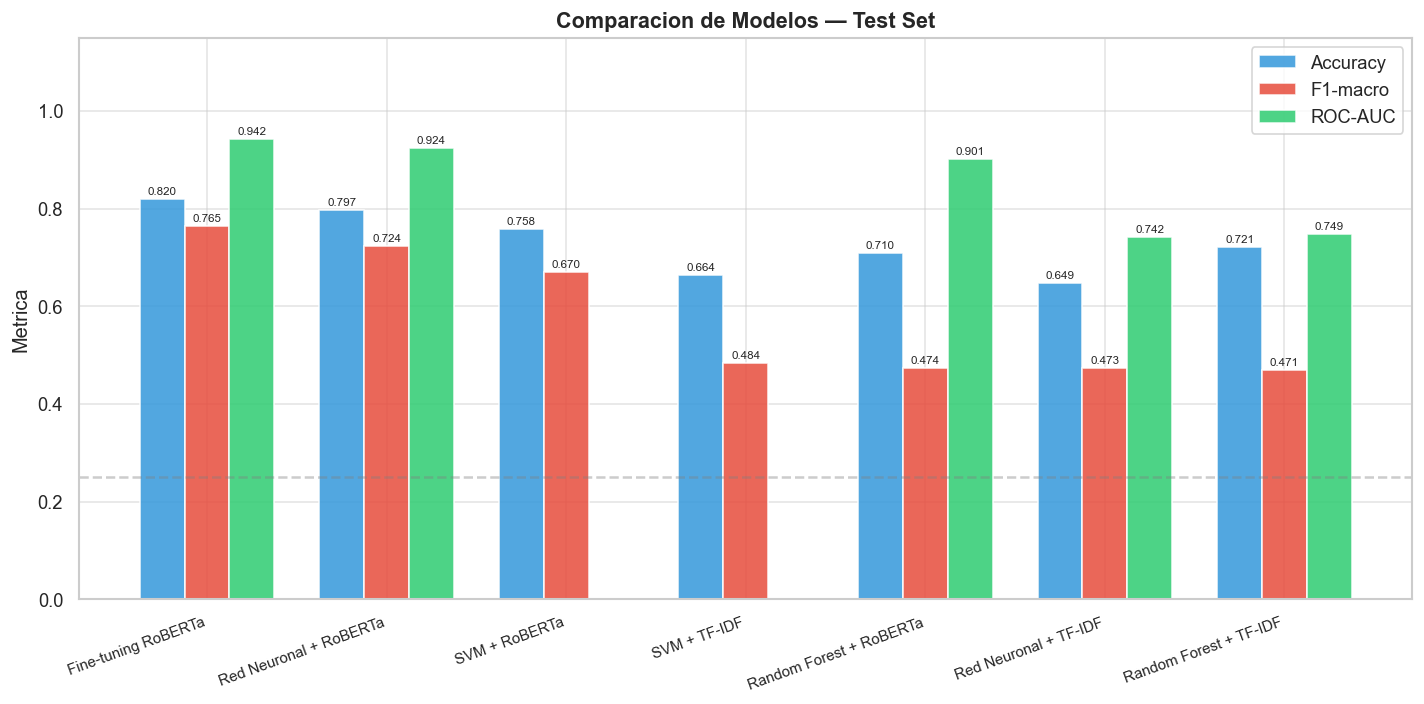

In [21]:
fig, ax = plt.subplots(figsize=(12, 6))

x      = np.arange(len(df_results))
width  = 0.25
bars1  = ax.bar(x - width, df_results['Accuracy'], width, label='Accuracy', color='#3498db', alpha=0.85)
bars2  = ax.bar(x,          df_results['F1-macro'], width, label='F1-macro', color='#e74c3c', alpha=0.85)
bars3  = ax.bar(x + width,  df_results['ROC-AUC'],  width, label='ROC-AUC',  color='#2ecc71', alpha=0.85)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        h = bar.get_height()
        if not np.isnan(h):
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.005,
                    f'{h:.3f}', ha='center', va='bottom', fontsize=7)

ax.set_title('Comparacion de Modelos — Test Set', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(df_results['Modelo'], rotation=20, ha='right', fontsize=9)
ax.set_ylabel('Metrica')
ax.set_ylim(0, 1.15)
ax.legend()
ax.axhline(y=1/n_classes, color='gray', linestyle='--', alpha=0.4, label='Baseline aleatorio')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '21_model_comparison.png'), bbox_inches='tight')
plt.show()

## 8. Interpretación de resultados

In [22]:
best_model = df_results.iloc[0]
print('=' * 65)
print('INTERPRETACION')
print('=' * 65)
print(f'\nMejor modelo: {best_model["Modelo"]}')
print(f'  F1-macro: {best_model["F1-macro"]:.4f}')
print(f'  Accuracy: {best_model["Accuracy"]:.4f}')
print()
print('Analisis por representacion vectorial:')
for rep in ['TF-IDF', 'RoBERTa', 'Word2Vec']:
    subset = df_results[df_results['Modelo'].str.contains(rep)]
    if len(subset) > 0:
        mean_f1 = subset['F1-macro'].mean()
        print(f'  {rep:10s} — F1-macro medio: {mean_f1:.4f}')
print()
print('Relacion con hipotesis:')
print('  H2 (ventaja embeddings contextuales): verificar si RoBERTa supera TF-IDF')
print('  H4 (polarizacion y carga emocional): se investigara en Notebook 4')
print()
print('Ficheros guardados en results/:')
result_files = [f for f in os.listdir(RESULTS_DIR) if f.startswith('1') or f.startswith('2')]
for f in sorted(result_files):
    print(f'  {f}')

INTERPRETACION

Mejor modelo: Fine-tuning RoBERTa
  F1-macro: 0.7652
  Accuracy: 0.8200

Analisis por representacion vectorial:
  TF-IDF     — F1-macro medio: 0.4761
  RoBERTa    — F1-macro medio: 0.6583

Relacion con hipotesis:
  H2 (ventaja embeddings contextuales): verificar si RoBERTa supera TF-IDF
  H4 (polarizacion y carga emocional): se investigara en Notebook 4

Ficheros guardados en results/:
  10_vectorization_comparison.png
  11_cm_svm_tfidf.png
  12_cm_svm_roberta.png
  13_cm_rf_tfidf.png
  14_cm_rf_roberta.png
  15_cm_nn_tfidf.png
  16_learning_curve_nn_tfidf.png
  17_cm_nn_roberta.png
  18_learning_curve_nn_roberta.png
  19_cm_roberta_ft.png
  20_learning_curve_roberta_ft.png
  21_model_comparison.png
  22_vader_by_veracity.png
  23_sentiment_distribution.png
  24_textblob_analysis.png
  25_polarization_indicators.png
  26_correlation_heatmap.png
  27_emotion_by_event.png
  28_radar_emotional_profile.png
